In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.stem.snowball import SnowballStemmer
from nltk.tokenize import RegexpTokenizer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

import re
import string

from wordcloud import WordCloud
 
# nltk.download('punkt')
# nltk.download('stopwords')
# nltk.download('wordnet')

In [ ]:
#!pip install pandas openpyxlº  

In [87]:
path_file_codebook = r"./data/Codebook - Feminism and Anti-feminism.xlsx"

df_codebook = pd.read_excel(path_file_codebook)

df_codebook.head()

,ID,Code,Definition,Survey question / comments,Category,Sub-category,Feminism Stance
0,1,Equating feminism and machismo,"They do not deny discrimination against women,...","""Tan peligroso es el machismo como el feminism...",Antifeminism,Explicit,Strongly opposing feminism
1,2,Denying the necessity of feminism,Emphasizing equality as the real goal and impl...,"""Lo importante no es el feminismo ni el machis...",Antifeminism,Explicit,Moderatedly opposing feminism
2,3,Minimizing gender inequality at the workplace,Skepticism about gender inequality in the work...,"""Las mujeres exageran los problemas que tienen...",Antifeminism,Latent,Opposing feminist issues
3,4,Supporting paternalistic behaviours,Defending the persistence of paternalistic beh...,"""Los hombres deberían proteger a las mujeres """,Antifeminism,Latent,Opposing feminist issues
4,5,Minimizing Sexual Harassment,Accusing women of overreacting to flirting or ...,"""Actualmente las mujeres malinterpretan cualqu...",Antifeminism,Latent,Opposing feminist issues


In [89]:
# relabeling and reorganizing columns for clarity

df_codebook = df_codebook.rename(columns={
    "ID": "id",
    'Code': 'label',
    'Definition': 'definition',
    'Survey question / comments': 'comments',
    'Category': 'category',
    'Sub-category': 'sub_category',
    'Feminism Stance': 'feminism_stance'
})

df_codebook = df_codebook[['id', 'comments', 'label', 'definition', 'category', 'sub_category', 'feminism_stance']]


In [90]:
df_codebook.head()

,id,comments,label,definition,category,sub_category,feminism_stance
0,1,"""Tan peligroso es el machismo como el feminism...",Equating feminism and machismo,"They do not deny discrimination against women,...",Antifeminism,Explicit,Strongly opposing feminism
1,2,"""Lo importante no es el feminismo ni el machis...",Denying the necessity of feminism,Emphasizing equality as the real goal and impl...,Antifeminism,Explicit,Moderatedly opposing feminism
2,3,"""Las mujeres exageran los problemas que tienen...",Minimizing gender inequality at the workplace,Skepticism about gender inequality in the work...,Antifeminism,Latent,Opposing feminist issues
3,4,"""Los hombres deberían proteger a las mujeres """,Supporting paternalistic behaviours,Defending the persistence of paternalistic beh...,Antifeminism,Latent,Opposing feminist issues
4,5,"""Actualmente las mujeres malinterpretan cualqu...",Minimizing Sexual Harassment,Accusing women of overreacting to flirting or ...,Antifeminism,Latent,Opposing feminist issues


In [91]:
df_codebook.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               48 non-null     int64 
 1   comments         21 non-null     object
 2   label            48 non-null     object
 3   definition       29 non-null     object
 4   category         48 non-null     object
 5   sub_category     28 non-null     object
 6   feminism_stance  48 non-null     object
dtypes: int64(1), object(6)
memory usage: 2.8+ KB


In [92]:
num_rows = df_codebook.shape[0]
num_cols = df_codebook.shape[1]
total_missing = df_codebook.isnull().sum().sum()

summary_text = f"""
Dataset overview – Codebook:

- Number of rows: {num_rows}
- Number of columns: {num_cols}
- Total missing values: {total_missing}

This dataset contains influencer comments and associated metadata. Some fields contain missing values.
""" #intead of \n

print(summary_text)



Dataset overview – Codebook:

- Number of rows: 48
- Number of columns: 7
- Total missing values: 66

This dataset contains influencer comments and associated metadata. Some fields contain missing values.



In [93]:
df_codebook.describe(exclude='number').T.sort_values(by = 'freq', ascending=False)

,count,unique,top,freq
category,48,5,Non-related content,19
sub_category,28,3,Latent,17
feminism_stance,48,12,Content niche,17
comments,21,21,"""Tan peligroso es el machismo como el feminism...",1
label,48,48,Equating feminism and machismo,1
definition,29,29,"They do not deny discrimination against women,...",1


In [117]:
from IPython.display import display, HTML

html_summary = """
<div style="font-family: Arial, sans-serif; font-size: 14px; color: #222; line-height: 1.6;">
  <b style="font-size:16px; color:#005f73;">✍️ Categorical Variables Summary:</b><br><br>
  <ul>
    <li><b>category:</b> 5 unique values, top = <i>"Non-related content"</i> (19)</li>
    <li><b>sub-category:</b> 3 unique values, top = <i>"Latent"</i> (17)</li>
    <li><b>feminism stance:</b> 12 unique values, top = <i>"Content niche"</i> (17)</li>
    <li><b>comments, label, definition:</b> mostly unique (21, 48, 29 respectively)</li>
  </ul>
  <p style="color:#555; font-style: italic;"margin-top: 5px;">
    This overview shows the diversity of categorical columns, highlighting which are mostly unique text and which are clear categories.
  </p>
</div>
"""

display(HTML(html_summary))


In [94]:
df_codebook['category'].unique()

array(['Antifeminism', 'Neutral', 'Feminism', 'Non-related content',
       'No content'], dtype=object)

In [ ]:
# What categories and feminism stances are associated with the "Latent" sub-category?

df_codebook[df_codebook['sub_category'] == 'Latent'][['category', 'sub_category', 'feminism_stance']]

,category,sub_category,feminism_stance
2,Antifeminism,Latent,Opposing feminist issues
3,Antifeminism,Latent,Opposing feminist issues
4,Antifeminism,Latent,Opposing feminist issues
5,Antifeminism,Latent,Opposing feminist issues
6,Antifeminism,Latent,Opposing feminist issues
10,Antifeminism,Latent,Opposing feminist issues
11,Antifeminism,Latent,Opposing feminist issues
12,Antifeminism,Latent,Opposing feminist issues
13,Antifeminism,Latent,Content expressing opinions or behaviors of a ...
16,Antifeminism,Latent,Opposing feminist issues


In [129]:
from IPython.display import display, HTML

html_content = """
<div style="font-family: Arial, sans-serif; font-size: 14px; color: #333; line-height: 3;">
✍️ The
  <b style="font-size:14x; color:#005f73;"> "Latent" sub-category </b> contains both  <span style="color: #d62828; font-weight:bold;">antifeminist</span> and <span style="color: #2a9d8f; font-weight:bold;">feminist</span> content, expressing opinions either opposing or supporting feminist issues

</div>
"""

display(HTML(html_content))

In [11]:
df_codebook[df_codebook['feminism_stance'] == 'Content niche']
#[['category', 'sub_category', 'feminism_stance']]

,id,code,definition,comments,category,sub_category,feminism_stance
28,30,Videogames,NaN,NaN,Non-related content,NaN,Content niche
29,31,Beauty,NaN,NaN,Non-related content,NaN,Content niche
30,32,Lifestyle (IRL),NaN,NaN,Non-related content,NaN,Content niche
31,33,Fitness,NaN,NaN,Non-related content,NaN,Content niche
32,34,Movies and TV Shows,NaN,NaN,Non-related content,NaN,Content niche
33,35,Music,NaN,NaN,Non-related content,NaN,Content niche
34,36,Humour,NaN,NaN,Non-related content,NaN,Content niche
35,37,Animals,NaN,NaN,Non-related content,NaN,Content niche
36,38,Cooking,NaN,NaN,Non-related content,NaN,Content niche
37,39,Coaching,NaN,NaN,Non-related content,NaN,Content niche


To provide visual insights, I decided to unify the following two labels into one: *'Content expressing opinions or behaviors of a sexist or anti-feminist nature, but the content does not directly address the feminism-antifeminism debate,'* and *'Exhibiting traditional gender stereotyping. Content expressing opinions or behaviors of a sexist or anti-feminist nature, but the content does not directly address the feminism-antifeminism debate.'*  The new label is **'Sexist Content without Debate'**

In [12]:
# New DataFrame with unify labels

visual_df_codebook = df_codebook.copy()  

visual_df_codebook['feminism_stance'] = visual_df_codebook['feminism_stance'].replace({
    'Content expressing opinions or behaviors of a sexist or anti feminist nature, but the content does not directly address the feminism-antifeminism debate.\n':
    'Sexist Content without Debate',    
    'Exhibiting traditional gender stereotyping. Content expressing opinions or behaviors of a sexist or anti feminist nature, but the content does not directly address the feminism-antifeminism debate.': 
    'Sexist Content without Debate'
})

In [43]:
import plotly.express as px

feminism_stance_counts = visual_df_codebook['feminism_stance'].value_counts(normalize=True) * 100
feminism_stance_counts = feminism_stance_counts.reset_index()
feminism_stance_counts.columns = ['feminism_stance', 'percentage']

fig = px.bar(
    feminism_stance_counts,
    x='percentage',
    y='feminism_stance',
    orientation='h',
    text=feminism_stance_counts['percentage'].apply(lambda x: f'{x:.1f}%'),
    title='Feminism Stances %',
    labels={'percentage':'Percentage', 'feminism_stance':''},
    color='percentage',
    color_continuous_scale='Viridis'
)

fig.update_traces(textposition='outside')
fig.update_layout(xaxis_range=[0, 45])

fig.show()


C:\Users\Celeste\AppData\Local\Temp\ipykernel_13916\3843725567.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='percentage',


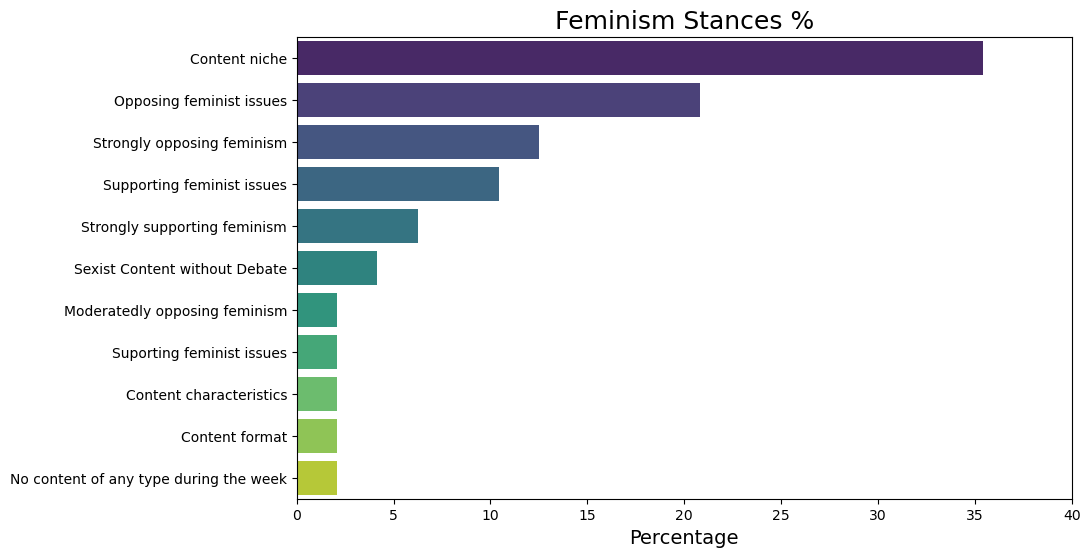

In [13]:
# Porcentajes
feminism_stance_counts = visual_df_codebook['feminism_stance'].value_counts(normalize=True) * 100
feminism_stance_counts = feminism_stance_counts.reset_index()
feminism_stance_counts.columns = ['feminism_stance', 'percentage']

plt.figure(figsize=(10, 6))
sns.barplot(x='percentage', 
            y='feminism_stance', 
            data=feminism_stance_counts,
            palette='viridis')

# Añadir títulos y etiquetas
plt.title("Feminism Stances %" , fontsize=18)
plt.xlabel("Percentage", fontsize=14)
plt.ylabel("")  
plt.xlim(0, 40)  

plt.show()


Preprocessing

In [14]:
df_codebook['category'].notna().value_counts()
df_codebook['category'].value_counts()

#note: not balanced! 

category
Non-related content    19
Antifeminism           18
Feminism                9
Neutral                 1
No content              1
Name: count, dtype: int64

In [15]:
nan_count = df_codebook['comments'].isna().sum()
non_nan_count = df_codebook['comments'].notna().sum()

print(f"Valores NaN: {nan_count}")
print(f"Valores no NaN: {non_nan_count}")

Valores NaN: 27
Valores no NaN: 21


In [16]:
# I took this next idea from: 

# https://www.kaggle.com/code/ankumagawa/sentimental-analysis-using-naive-bayes-classifier#3.-SENTIMENTAL-ANALYSIS:

#df_codebook['feminism_stance'].unique()

In [17]:
# Unify values in column 'feminism_stance'
df_codebook['feminism_stance'] = df_codebook['feminism_stance'].replace('Suporting feminist issues', 'Supporting feminist issues')

In [18]:
df_codebook['feminism_stance'].unique()

array(['Strongly opposing feminism', 'Moderatedly opposing feminism',
       'Opposing feminist issues',
       'Content expressing opinions or behaviors of a sexist or anti feminist nature, but the content does not directly address the feminism-antifeminism debate.\n',
       'Exhibiting traditional gender stereotyping. Content expressing opinions or behaviors of a sexist or anti feminist nature, but the content does not directly address the feminism-antifeminism debate.',
       'Strongly supporting feminism', 'Supporting feminist issues',
       'Content niche', 'Content characteristics', 'Content format',
       'No content of any type during the week'], dtype=object)

(-0.5, 799.5, 399.5, -0.5)

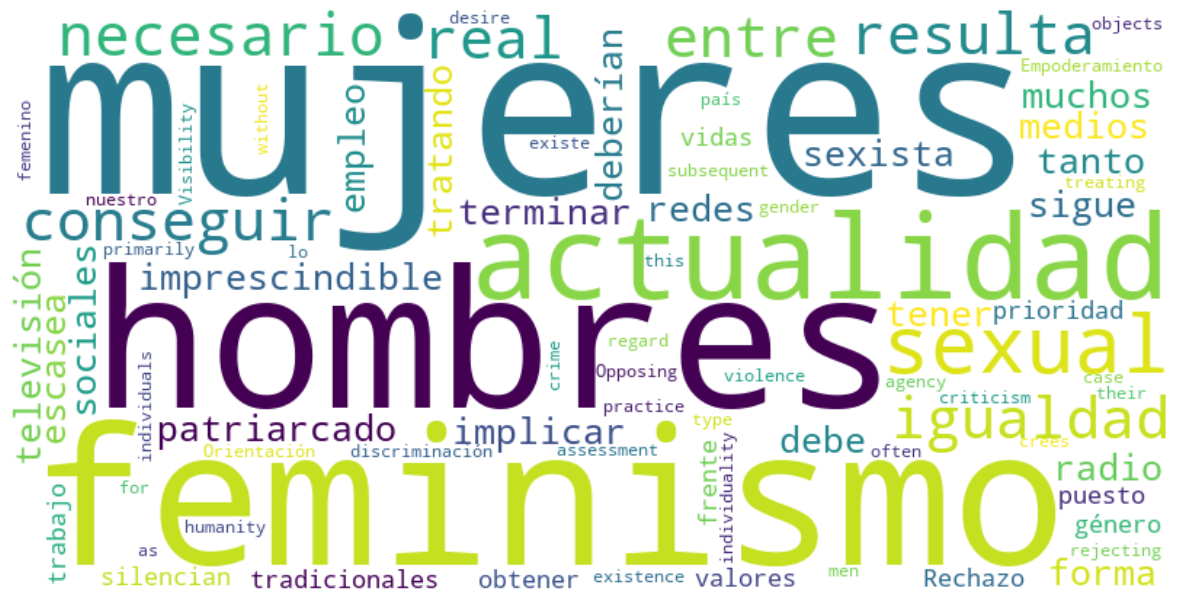

In [19]:
# Define positive stances
positive_stances = ['Strongly supporting feminism', 'Supporting feminist issues']

# Join comments for positive stances
text = " ".join(i for i in df_codebook[df_codebook['feminism_stance'].isin(positive_stances)]['comments'])

stopwords = set(['the', 'or', 'by','and','y', 'o', 'que', 'de', 'la', 'el', 'El', 'en', 'a', 'los', 'las', 'por', 'un', 'una', \
                 'con', 'su', 'se', 'del', 'es', 'no', 'para', 'más', 'este', 'esto', 'como','este', 'P22', 'tan',\
                      'donde', 'cuando', 'que', 'quien', 'mi', 'me', 'te', 'su', 'mismo', 'también', 'ser', 'hay', 'of'])

wordcloud = WordCloud(background_color="white", width=800, height=400, stopwords=stopwords).generate(text)

# Plott the word cloud
plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")

# What are people discussing? Topics with significant impact. Still a reality, still a patriarchy.

(-0.5, 799.5, 399.5, -0.5)

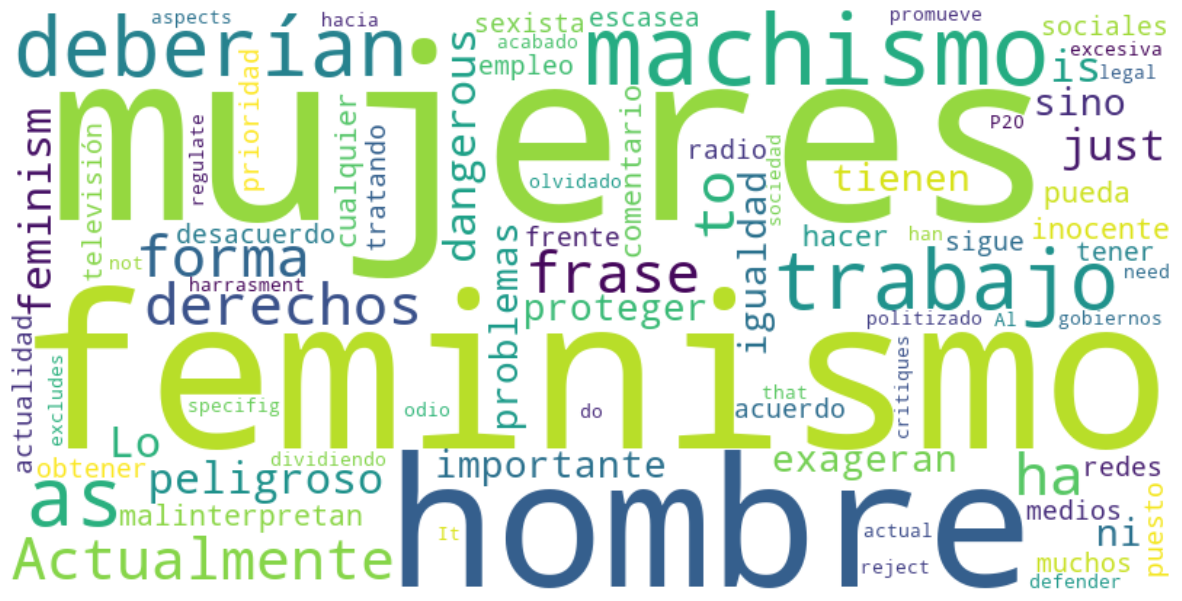

In [20]:
negative_stances = ['Strongly opposing feminism', 'Moderatedly opposing feminism', 'Opposing feminist issues',\
                    'Content expressing opinions or behaviors of a sexist or anti feminist nature, but the content does not directly address the feminism-antifeminism debate.\n',\
                    'Exhibiting traditional gender stereotyping. Content expressing opinions or behaviors of a sexist or anti feminist nature, but the content does not directly address the feminism-antifeminism debate.']

text = " ".join(i for i in df_codebook[df_codebook['feminism_stance'].isin(negative_stances)]['comments'] if pd.notna(i))

wordcloud = WordCloud(background_color="white", width=800, height=400, stopwords=stopwords).generate(text)

plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")


In [21]:
#Tokenization

import spacy
spacy_nlp = spacy.load("es_core_news_sm")

In [22]:
df_sentiment_analysis = df_codebook[['id', 'comments', 'category', 'sub_category']].copy()

df_sentiment_analysis.head(3)

,id,comments,category,sub_category
0,1,"""Tan peligroso es el machismo como el feminism...",Antifeminism,Explicit
1,2,"""Lo importante no es el feminismo ni el machis...",Antifeminism,Explicit
2,3,"""Las mujeres exageran los problemas que tienen...",Antifeminism,Latent


In [23]:
df_sentiment_analysis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            48 non-null     int64 
 1   comments      21 non-null     object
 2   category      48 non-null     object
 3   sub_category  28 non-null     object
dtypes: int64(1), object(3)
memory usage: 1.6+ KB


In [24]:
# Eliminar filas donde 'comments' es NaN
df_sentiment_analysis = df_sentiment_analysis.dropna(subset=['comments'])

df_sentiment_analysis.shape

(21, 4)

In [25]:
# Def regular expressions
REPLACE_NO_SPACE = re.compile(r"[.;:!\'¿?,#\"()\[\]]") 
REPLACE_WITH_SPACE = re.compile(r"(<br\s*/><br\s*/>)|(\-)|(\/)") 

def clean(comments):

    #remove special characters
    comments = re.sub(REPLACE_NO_SPACE, "", comments) 
    comments = re.sub(REPLACE_WITH_SPACE, " ", comments) 

    #preprocess with spaCy
    doc = spacy_nlp(comments)
    
    lemmas = []
    # entities = []
    
    for token in doc:
        if not token.is_punct and not token.is_space and not token.is_stop:
            lemmas.append(token.lemma_.lower()) 

 # for ent in doc.ents:
    #     entities.append((ent.text, ent.label_))
    
    return lemmas #, entities

Attributes in spaCy
- is_punct: A boolean attribute that indicates whether the token is a punctuation mark.
- pos_: The part of speech (POS) of the token, such as noun, verb, adjective, etc.
- text: The original text of the token as it appears in the input text.

In [26]:
# Sanity check
text = df_sentiment_analysis['comments'][3]

print('before cleaning: ', text)
print('\n')
print('after cleaning: ', clean(text))

before cleaning:  "Los hombres deberían proteger a las mujeres "


after cleaning:  ['hombre', 'deber', 'proteger', 'mujer']


In [27]:
# this step is redundant, do not need to do it, you do it in the next step
# df_sentiment_analysis['tokenized_comments'] = df_sentiment_analysis.comments.apply(clean) 

In [28]:
vectoriser = TfidfVectorizer(analyzer=clean)
data_tfidf = vectoriser.fit_transform(df_sentiment_analysis.comments)

In [29]:
# Save the vector space in a list
vector_space = vectoriser.get_feature_names_out()

In [30]:
len(vector_space) #the vectoriser has found 162 unique features (words)

121

## Sentiment Analysis

### Hugging face 🤗

In [31]:
from pysentimiento import create_analyzer

analyzer = create_analyzer(task="sentiment", lang="es")

c:\Users\Celeste\anaconda3\envs\data-science\Lib\site-packages\transformers\tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [32]:
def predict_sentiment(comment):
    
    sentiment = analyzer.predict(comment).output #without output we get all the "probas"
    
    if sentiment == 'POS':
        return 'POSITIVE'
    elif sentiment == 'NEG':
        return 'NEGATIVE'
    else:
        return 'NEUTRAL'

In [33]:
df_sentiment_analysis['sentiment'] = df_sentiment_analysis['comments'].apply(predict_sentiment)

df_sentiment_analysis.head(3)

,id,comments,category,sub_category,sentiment
0,1,"""Tan peligroso es el machismo como el feminism...",Antifeminism,Explicit,NEGATIVE
1,2,"""Lo importante no es el feminismo ni el machis...",Antifeminism,Explicit,NEUTRAL
2,3,"""Las mujeres exageran los problemas que tienen...",Antifeminism,Latent,NEGATIVE


# Visual insights

In [34]:
summary = df_sentiment_analysis.groupby(['category', 'sentiment']).size().reset_index(name='count')
summary['percent'] = summary.groupby('category')['count'].transform(lambda x: 100 * x / x.sum())

print(summary)


       category sentiment  count    percent
0  Antifeminism  NEGATIVE      9  75.000000
1  Antifeminism   NEUTRAL      3  25.000000
2      Feminism  NEGATIVE      6  66.666667
3      Feminism   NEUTRAL      2  22.222222
4      Feminism  POSITIVE      1  11.111111


In [35]:
colors = ['#2A9D8F', '#E76F51', '#264653']  

fig = px.bar(df_perc,
             x='percent',
             y='category',
             color='sentiment',
             orientation='h',
             color_discrete_sequence=colors,
             text=df_perc['percent'].apply(lambda x: f'{x:.1f}%'),
             title='Sentiment Distribution by Category (%)',
             labels={'percent':'Percentage (%)', 'category':'Category'})

fig.update_traces(textposition='outside')
fig.update_layout(barmode='stack',
                  yaxis=dict(title='Category'),
                  xaxis=dict(title='Percentage (%)'),
                  legend_title_text='Sentiment',
                  plot_bgcolor='white',

                  
                  paper_bgcolor='white',
                  font=dict(family='Arial', size=14))

fig.show()


NameError: name 'px' is not defined

In [ ]:
def generate_sentiment_storytelling(df_summary):
    storytelling = ""

    for category in df_summary['category'].unique():
        subset = df_summary[df_summary['category'] == category]

        neg = subset[subset['sentiment'] == 'NEGATIVE']['percent'].values
        neg = neg[0] if len(neg) > 0 else 0

        neu = subset[subset['sentiment'] == 'NEUTRAL']['percent'].values
        neu = neu[0] if len(neu) > 0 else 0

        pos = subset[subset['sentiment'] == 'POSITIVE']['percent'].values
        pos = pos[0] if len(pos) > 0 else 0

        storytelling += (
            f"In the **{category}** category, most comments show a {neg:.1f}% negative tone and "
            f"{neu:.1f}% neutral tone. Positive comments are fewer, representing only {pos:.1f}%.\n\n"
        )

    storytelling += (
        "Overall, the debate is mostly critical or neutral, with limited explicit support. "
        "Neutral comments might reflect a lack of strong opinions or areas where dialogue could improve."
    )
    return storytelling


# Uso:
print(generate_sentiment_storytelling(summary))


In the **Antifeminism** category, most comments show a 75.0% negative tone and 25.0% neutral tone. Positive comments are fewer, representing only 0.0%.

In the **Feminism** category, most comments show a 66.7% negative tone and 22.2% neutral tone. Positive comments are fewer, representing only 11.1%.

Overall, the debate is mostly critical or neutral, with limited explicit support. Neutral comments might reflect a lack of strong opinions or areas where dialogue could improve.
